In [100]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.power import TTestPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd


## Create Synthetic Dataset

In [101]:
# set the number of rows
n = 80

# generate the data set

# create the categorical variables
# create the constant of 1 virus
virus = ['Influenza_B'] * n

# create temperature blocks


# create the surfaces in the data set by assigning each equaly
surface = ["Stainless_Steel"] * 20 + ["Plastic"] * 20 + ["Granite"] * 20 + ["Glass"] * 20

# create the options for disinfectant
# need to select the two things equaly within each value of surface
disinfectant = []
for i in range(4):
    disinfectant.extend(["Control"] * 10 + ["Disinfectant"] * 10)

# create the application method
application = []
for i in range(8):
    application.extend(["Wipes"] * 5 + ["Spray"] * 5)

# create temperature block
temp_block = []
for i in range(16):
    temp_block.extend(["Cold"] + ["Cool"] + ["Mid"] + ["Warm"] + ["Hot"])

# create dataframe containing the categorical variables
df = pd.DataFrame({
    "Virus": virus,
    "Surface": surface,
    "Disinfectant": disinfectant,
    "Application" : application,
    "Temp_Block" : temp_block
})

print(df.columns)

# create continuous variables and add them to the dataframe
# use random seed to ensure replicability
np.random.seed(42)

# create the random values for temperature
def get_temp(temp_block):
    if temp_block == "Cold":
        return np.random.uniform(15,18)
    elif temp_block == "Cool":
        return np.random.uniform(18,21)
    elif temp_block == "Mid":
        return np.random.uniform(21,24)
    elif temp_block == "Warm":
        return np.random.uniform(24,27)
    else:
        return np.random.uniform(27,30)
df['Temperature_Celsius'] = df['Temp_Block'].apply(get_temp).round(2)

# function to create the random values for porosity based on surface
def get_porosity(surface):
    if surface == "Stainless_Steel":
        return np.random.uniform(0,0.2) #range determined from avg porosity of stainless steel
    elif surface == "Plastic":
        return 0
    elif surface == "Granite":
        return np.random.uniform(0.05,1.5) # range determined from avg. porosity of granite
    else:
        return 0

df['Porosity'] = df['Surface'].apply(get_porosity).round(2) #run function using surface as input
#df['Porosity'] = df['Porosity'].round(2) #add to dataframe and round


# create random values for time based on all input variables

# set seed for reproducibility
np.random.seed(42)

# empty list
time_list = []


# loop to create all time values based on inputs
for i, row in df.iterrows():
    if row["Disinfectant"] == "Control":
        # control: 24–48 h in minutes
        if row["Surface"] == "Stainless_Steel":
            time = np.random.randint(1900, 2100)
        elif row["Surface"] == "Plastic":
            time = np.random.randint(1800, 2000)
        elif row["Surface"] == "Granite":
            time = np.random.randint(2000, 2200)
        else:  # glass
            time = np.random.randint(1850, 2050)

    else:
        # disinfectant: spray slightly faster than wipes
        if row["Surface"] == "Stainless_Steel":
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 14)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 5)

        elif row["Surface"] == "Plastic":
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 13)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 6)

        elif row["Surface"] == "Granite":
            if row["Application"] == "Wipes":
                time = np.random.randint(10, 15)
            elif row["Application"] == "Spray":
                time = np.random.randint(3, 7)

        else:  # glass
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 12)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 5)

    #add explicit application significance
    if row["Application"] == "Spray" and row["Disinfectant"] == "Disinfectant":
        time = max(1, time - 4)

    time_list.append(time)
# assign time values to the dataframe
df["Time"] = time_list

# add new columns for crossover/washout RCT

# create empty lists
application_2_list = []
time_2_list = []

# assign new applications that are opposite of original application
for i, row in df.iterrows():

    # flip application
    if row["Application"] == "Wipes":
        app2 = "Spray"
    else:
        app2 = "Wipes"

    application_2_list.append(app2)

    # create Time_2
    time2 = row["Time"]

    if app2 == "Spray":
        time2 = time2 + 2.0 #ensure slight effect that spray to wipes is better than wipes to spray

    time_2_list.append(time2)

# add new columns to dataframe
df["Application_2"] = application_2_list
df["Time_2"] = time_2_list

# add new columns for withdrawal RCT

# subset data to only use the 'Disinfectant' rows
df_w = df[df["Disinfectant"] == "Disinfectant"].copy()

# assign withdrawal status (50/50 split)
np.random.seed(42)
mask = np.random.rand(len(df_w)) < 0.5
df_w['Withdrawal_Status'] = np.where(mask, 'Continued', 'Withdrawn')

# generate viral load data (T1 = baseline, T2 = after withdrawal period)
df_w['Viral_Load_T1'] = np.random.uniform(5, 15, len(df_w))

def calculate_rebound(row):
    if row['Withdrawal_Status'] == 'Withdrawn':
        # High rebound because disinfectant was stopped
        return row['Viral_Load_T1'] + np.random.uniform(100, 300)
    else:
        # Low rebound because disinfectant continued
        return row['Viral_Load_T1'] + np.random.uniform(0, 20)

df_w['Viral_Load_T2'] = df_w.apply(calculate_rebound, axis=1)

# merge subset data back to original df
# merging creates NaN for original Control group rows
df = df.merge(
    df_w[['Withdrawal_Status', 'Viral_Load_T1', 'Viral_Load_T2']],
    left_index=True,
    right_index=True,
    how='left'
)


# create matched pairs for matched pairs RCT

# shuffle data to avoid pairing bias
np.random.seed(42)
df = df.sample(frac=1).reset_index(drop=True)

# create empty column
df["Pair_ID"] = np.nan

pair_id = 1 #set starting pair id

# group by the controlled variables
for (surface, disinfectant), group in df.groupby(["Surface", "Disinfectant"]):
    wipe_rows = group[group["Application"] == "Wipes"].index.tolist()
    spray_rows = group[group["Application"] == "Spray"].index.tolist()

    # ensure equal matching
    n_pairs = min(len(wipe_rows), len(spray_rows))

    for i in range(n_pairs):
        df.loc[wipe_rows[i], "Pair_ID"] = pair_id
        df.loc[spray_rows[i], "Pair_ID"] = pair_id
        pair_id += 1

# convert to integer
df["Pair_ID"] = df["Pair_ID"].astype("Int64")

df.head(25)

Index(['Virus', 'Surface', 'Disinfectant', 'Application', 'Temp_Block'], dtype='object')


,Virus,Surface,Disinfectant,Application,Temp_Block,Temperature_Celsius,Porosity,Time,Application_2,Time_2,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2,Pair_ID
0,Influenza_B,Plastic,Disinfectant,Wipes,Cold,16.82,0.00,10,Spray,12.0,Continued,14.695846,17.087731,26
1,Influenza_B,Stainless_Steel,Control,Wipes,Cold,16.12,0.17,2002,Spray,2004.0,NaN,NaN,NaN,31
2,Influenza_B,Plastic,Control,Wipes,Mid,21.88,0.00,1991,Spray,1993.0,NaN,NaN,NaN,21
3,Influenza_B,Plastic,Disinfectant,Wipes,Cool,18.51,0.00,10,Spray,12.0,Withdrawn,12.751328,255.400286,27
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,Warm,25.30,0.01,1,Wipes,1.0,Withdrawn,10.467103,287.909651,36
5,Influenza_B,Plastic,Control,Spray,Warm,25.78,0.00,1888,Wipes,1888.0,NaN,NaN,NaN,21
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,Cold,15.06,0.02,10,Spray,12.0,Continued,6.220382,23.482451,36
7,Influenza_B,Glass,Disinfectant,Wipes,Cold,17.32,0.00,11,Spray,13.0,Withdrawn,12.722448,170.672738,6
8,Influenza_B,Stainless_Steel,Control,Wipes,Hot,27.47,0.06,2006,Spray,2008.0,NaN,NaN,NaN,32
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,Mid,23.50,0.15,10,Spray,12.0,Withdrawn,5.343885,171.523490,37


In [102]:
df.describe()

,Temperature_Celsius,Porosity,Time,Time_2,Viral_Load_T1,Viral_Load_T2,Pair_ID
count,80.000000,80.000000,80.000000,80.000000,40.000000,40.000000,80.0
mean,22.398500,0.222375,995.875000,996.875000,9.755146,108.291190,20.5
std,4.324053,0.398755,998.382748,998.391293,3.188626,107.530005,11.616226
min,15.060000,0.000000,1.000000,1.000000,5.055221,5.960655,1.0
25%,18.487500,0.000000,7.000000,8.500000,6.932008,17.868600,10.75
50%,22.550000,0.005000,916.500000,918.000000,9.419271,26.179509,20.5
75%,26.150000,0.162500,1994.500000,1996.000000,12.729668,209.621496,30.25
max,29.960000,1.400000,2189.000000,2191.000000,14.868869,287.909651,40.0


## Exploratory Data Analysis

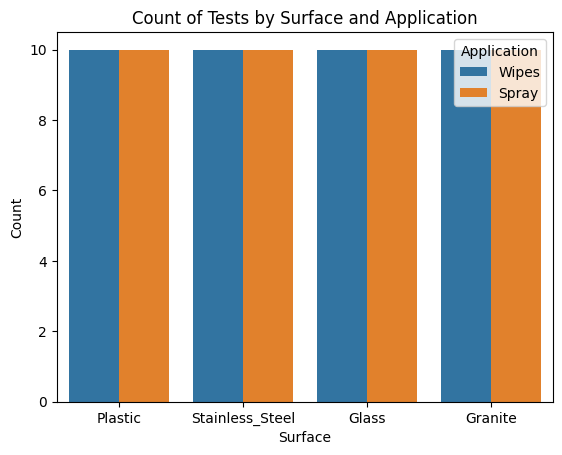

In [103]:
# create a bar chart to look at the count of application instances by surface
# shows that there is an equal number of wipe and spary applications for each surface
sns.countplot(x="Surface", hue="Application", data = df)

plt.title('Count of Tests by Surface and Application')
plt.ylabel('Count')
plt.xlabel('Surface')
plt.show()

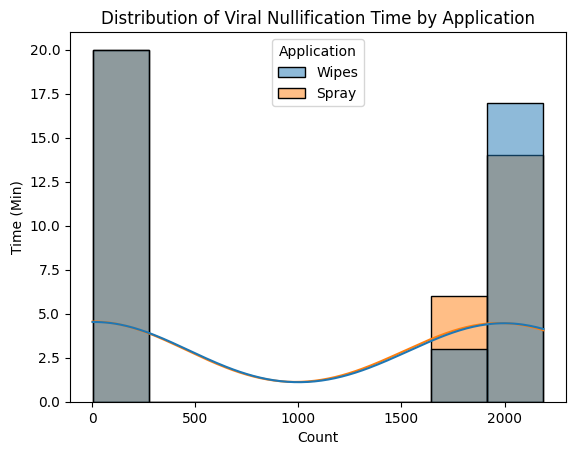

In [104]:
# histogram for time
# looks at the time distribution to nullify the virus by application type
# shows that there is little difference in application for the disinfectant group
# shows that there is slightly higher nullificaiton time for wipes than spray for the control group

sns.histplot(x="Time", kde=True, hue="Application" ,data=df)

plt.title('Distribution of Viral Nullification Time by Application')
plt.ylabel('Time (Min)')
plt.xlabel('Count')
plt.show()

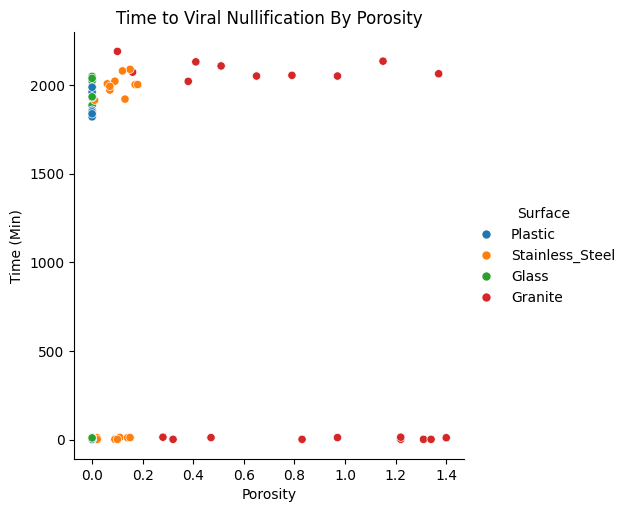

In [105]:
# Scatter plot to visualize relationship between porosiy, surface, application and time
# shows that there is some range in porosity for stainless steel and granite
# shows that there is no visual relationship between prorosity or surface and time to viral nullification
sns.relplot(data=df, x='Porosity', y='Time', hue='Surface')

plt.title('Time to Viral Nullification By Porosity')
plt.ylabel('Time (Min)')
plt.xlabel('Porosity')
plt.show()

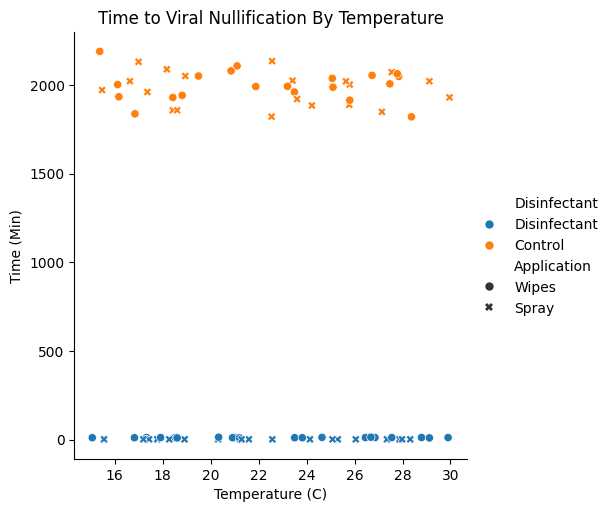

In [106]:
#Time vs Tempature with Surface
# Shows that there is a large time differential to viral nullification between disinfectant and control
# There is no clear pattern of time to nullification based on temperature or application
sns.relplot(data=df, x='Temperature_Celsius', y='Time', hue="Disinfectant", style='Application')


plt.title('Time to Viral Nullification By Temperature')
plt.ylabel('Time (Min)')
plt.xlabel('Temperature (C)')
plt.show()




In [107]:
# Create long dataframe for visualization of the viral load across time

# select the relevant columns
df_plot = df[['Viral_Load_T1', 'Viral_Load_T2', 'Withdrawal_Status']].copy()

# drop rows with nulls
df_plot = df_plot.dropna(subset=['Viral_Load_T1', 'Viral_Load_T2'])

# melt T1 and T2 into one column
df_long = pd.melt(
    df_plot,
    id_vars=['Withdrawal_Status'],
    value_vars=['Viral_Load_T1', 'Viral_Load_T2'],
    var_name='Time_Point',
    value_name='Viral_Load'
)

# rename for clarity
df_long['Time_Point'] = df_long['Time_Point'].map({'Viral_Load_T1': 'T1', 'Viral_Load_T2': 'T2'})



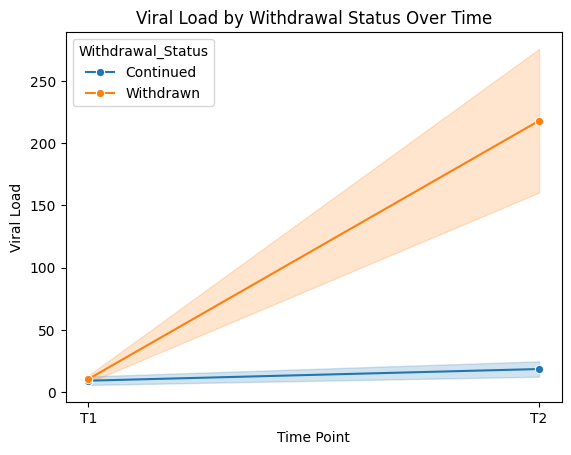

In [108]:
#Viral Load vs Withdrawl Status
# Shows that there is a large difference in viral load between those that continued to receive disinfectant
# and those that later received control

sns.lineplot(
    data=df_long,
    x='Time_Point',
    y='Viral_Load',
    hue='Withdrawal_Status',
    marker='o',
    errorbar="sd"
)

plt.title('Viral Load by Withdrawal Status Over Time')
plt.ylabel('Viral Load')
plt.xlabel('Time Point')
plt.show()

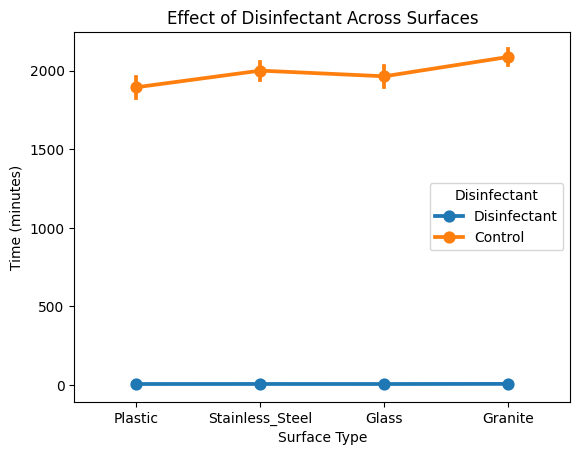

In [109]:

#Disinfectant vs Surface
# Shows that there are slight differences between the time to nullificaiton for surface when recieving the control
# This pattern is not visible for the surfaces that received disinfectant

sns.pointplot(
    data=df,
    x="Surface",
    y="Time",
    hue="Disinfectant",
    errorbar="sd"
)

plt.title("Effect of Disinfectant Across Surfaces")
plt.ylabel("Time (minutes)")
plt.xlabel("Surface Type")

plt.show()

## Parallel Randomized Control Trial

In [110]:
# Subset data for Parallel RCT
df_parallel = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_parallel.head()

,Virus,Surface,Disinfectant,Application,Time,Temperature_Celsius,Temp_Block
0,Influenza_B,Plastic,Disinfectant,Wipes,10,16.82,Cold
1,Influenza_B,Stainless_Steel,Control,Wipes,2002,16.12,Cold
2,Influenza_B,Plastic,Control,Wipes,1991,21.88,Mid
3,Influenza_B,Plastic,Disinfectant,Wipes,10,18.51,Cool
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,1,25.30,Warm


### Hypothesis
Main Effect Disinfectant:  
H0: There is no difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.
    
Main Effect Application:  
H0: There is no difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature.  


### ANOVA
##### Testing the interaction between Disinfectant and Application Method

In [111]:
#ANOVA 1: Testing the interaction between Disinfectant and Application Method
# This checks if 'Spray' vs 'Wipes' actually changes the 'Time' outcome  differently depending on whether it's a Control or Disinfectant.

# standard blocked ANOVA
model_anova1 = smf.ols(
    "Time ~ C(Disinfectant) + C(Application) + C(Temp_Block)",
    data=df_parallel
).fit()

anova_results_1 = anova_lm(model_anova1, typ=2)

print("\nANOVA 1: Disinfectant + Application")
print(anova_results_1)


ANOVA 1: Disinfectant + Application
                      sum_sq    df             F        PR(>F)
C(Disinfectant)  78415920.20   1.0  17836.051673  5.543569e-89
C(Application)       5024.45   1.0      1.142834  2.885766e-01
C(Temp_Block)        2792.75   4.0      0.158806  9.583918e-01
Residual           320943.35  73.0           NaN           NaN


### Pairwise Tukey Test

In [112]:
# Tukey HSD for Application
tukey_app = pairwise_tukeyhsd(
    endog=df["Time"], #continuous outcome
    groups=df["Disinfectant"], #grouping variable
    alpha=0.05
)

print(tukey_app)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1    group2    meandiff p-adj   lower      upper    reject
----------------------------------------------------------------
Control Disinfectant  -1980.1   0.0 -2009.0012 -1951.1988   True
----------------------------------------------------------------


### Power Analysis

Power analysis was conducted without blocking, making it a conservative estimate. Inclusion of temperature blocks is expected to increase statistical power.

In [113]:
# Model blocking factor only
block_model = smf.ols("Time ~ C(Temp_Block)", data=df_parallel).fit()

# Residuals = Time adjusted for temperature
df_parallel["Time_adj"] = block_model.resid

# Groups by application (using adjusted values)
groups = [
    df_parallel[df_parallel["Application"] == "Wipes"]["Time_adj"].values,
    df_parallel[df_parallel["Application"] == "Spray"]["Time_adj"].values,
]

# Grand mean
data = np.concatenate(groups)
grand_mean = np.mean(data)

# Sum of squares
ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
ss_within = sum(np.sum((g - np.mean(g)) ** 2) for g in groups)

# Cohen's f (adjusted for block)
effect_size = np.sqrt(ss_between / ss_within)
print(f"Cohen's f (Application effect, blocked): {effect_size:.2f}")

power_analysis = FTestAnovaPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=2
)

print(f"Required sample size per group (blocked design): {sample_size:.0f}")

Cohen's f (Application effect, blocked): 0.01
Required sample size per group (blocked design): 122999


## Factorial Randomized Control Trial

In [114]:
# subset dataset for factorial RCT
df_factorial = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

#df[df["Disinfectant"] == "Disinfectant"].copy()


### Hypothesis
Main Effect Disinfectant:  
H0: There is no difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.
    
Main Effect Application Method:  
H0: There is no difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature.
   
Main Effect Surface:  
H0: There is no difference in mean time to nullify the virus between surfaces, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between surfaces, after controlling for temperature.  
  
Interaction Effect Application x Surface:  
H0: There is no interaction between application method and surface, the effect of application method on time to nullify the virus is the same for all surfaces, after controlling for temperature.  
H1: There is an interaction between application method and surface, the effect of application method on time to nullify the virus depends on the surface type, after controlling for temperature.


### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [115]:
# two-way factorial ANOVA

# We use 'Time' as the dependent variable to see if disinfectant application effectiveness depends
# on the specific surface it's applied to.

model = smf.ols('Time ~ C(Disinfectant) + C(Application) + C(Surface) +C(Temp_Block) + C(Application):C(Surface)',
            data=df_factorial).fit()

anova_table = anova_lm(model, typ=2)
print("Two-way Factorial ANOVA Table:\n")
print(anova_table)

Two-way Factorial ANOVA Table:

                                sum_sq    df             F        PR(>F)
C(Disinfectant)            78415920.20   1.0  23685.734768  3.758179e-87
C(Application)                 5024.45   1.0      1.517648  2.222818e-01
C(Surface)                    97586.25   3.0      9.825394  1.868174e-05
C(Temp_Block)                  2792.75   4.0      0.210889  9.315249e-01
C(Application):C(Surface)      1541.45   3.0      0.155200  9.259868e-01
Residual                     221815.65  67.0           NaN           NaN


### Pairwise Tukey Test

In [116]:
# Post-hoc Tukey HSD
# look at the interaction between surfaces

# Run pairwise Tukey HSD
tukey_surface = pairwise_tukeyhsd(
    endog=df_factorial['Time'],
    groups=df_factorial['Surface'],
    alpha=0.05
)

print(tukey_surface)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1      group2     meandiff p-adj    lower    upper   reject
-----------------------------------------------------------------
  Glass         Granite    62.05 0.9974 -782.9584 907.0584  False
  Glass         Plastic   -34.85 0.9995 -879.8584 810.1584  False
  Glass Stainless_Steel     18.1 0.9999 -826.9084 863.1084  False
Granite         Plastic    -96.9 0.9904 -941.9084 748.1084  False
Granite Stainless_Steel   -43.95 0.9991 -888.9584 801.0584  False
Plastic Stainless_Steel    52.95 0.9984 -792.0584 897.9584  False
-----------------------------------------------------------------


### Power Analysis

In [117]:
# conduct power analysis calculating effect size from data

# model with blocking factor only
block_model = smf.ols("Time ~ C(Temp_Block)", data=df_factorial).fit()
df_factorial["Time_adj"] = block_model.resid

# Create groupings by surface
groups = [
    group["Time_adj"].dropna()
    for _, group in df_factorial.groupby(["Surface", "Application"])
]

# Calculate mean of combined data
dataFact = np.concatenate(groups)
dataFact_mean = np.mean(dataFact)

# Calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - dataFact_mean) ** 2
    for group in groups
)

# Calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups
)

# Calculate effect size using Cohen's f
effect_size = np.sqrt(ss_between / ss_within)

# Display effect size result
print(f'Effect size: {effect_size:.2f}')

# Conduct power analysis
power_analysis = FTestAnovaPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=len(groups)
)

# Display power analysis result
print(f'The sample size required per group is: {sample_size:.0f}')

Effect size: 0.04
The sample size required per group is: 10842


## Crossover Randomized Control Trial

### Subset the Data

In [118]:
# subset data to create new data set crossover RCT
df_crossover = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Application_2",
    "Time_2",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_crossover.head(10)
print(df_crossover.columns) #checking column names

Index(['Virus', 'Surface', 'Disinfectant', 'Application', 'Time',
       'Application_2', 'Time_2', 'Temperature_Celsius', 'Temp_Block'],
      dtype='object')


In [119]:
# filter to only disinfectant rows — crossover of application
df_crossover = df_crossover[df_crossover["Disinfectant"] == "Disinfectant"].copy()

# create a Sequence column to track the order of treatments
df_crossover["Sequence"] = (
    df_crossover["Application"] + "_then_" + df_crossover["Application_2"]
)

# 1. Create the Subject ID BEFORE splitting
df_crossover["Subject_ID"] = range(1, len(df_crossover) + 1)

# 2. Period 1: Grab Subject_ID, Treatment, Outcome, Sequence, and Temp_Block
df_period1 = df_crossover[["Subject_ID", "Surface", "Application", "Time", "Sequence", "Temp_Block"]].copy()
df_period1.rename(columns={"Application": "Treatment", "Time": "Outcome"}, inplace=True)
df_period1["Period"] = "Period_1"

# 3. Period 2: Grab the exact same columns for the second time period
df_period2 = df_crossover[["Subject_ID", "Surface", "Application_2", "Time_2", "Sequence", "Temp_Block"]].copy()
df_period2.rename(columns={"Application_2": "Treatment", "Time_2": "Outcome"}, inplace=True)
df_period2["Period"] = "Period_2"

# 4. Combine into one long dataframe and sort so pairs sit next to each other
df_crossover_long = pd.concat([df_period1, df_period2], ignore_index=True)
df_crossover_long.sort_values(by=["Subject_ID", "Period"], inplace=True)

print("Crossover long format shape:", df_crossover_long.shape)
display(df_crossover_long.head(10))

Crossover long format shape: (80, 7)


,Subject_ID,Surface,Treatment,Outcome,Sequence,Temp_Block,Period
0,1,Plastic,Wipes,10.0,Wipes_then_Spray,Cold,Period_1
40,1,Plastic,Spray,12.0,Wipes_then_Spray,Cold,Period_2
1,2,Plastic,Wipes,10.0,Wipes_then_Spray,Cool,Period_1
41,2,Plastic,Spray,12.0,Wipes_then_Spray,Cool,Period_2
2,3,Stainless_Steel,Spray,1.0,Spray_then_Wipes,Warm,Period_1
42,3,Stainless_Steel,Wipes,1.0,Spray_then_Wipes,Warm,Period_2
3,4,Stainless_Steel,Wipes,10.0,Wipes_then_Spray,Cold,Period_1
43,4,Stainless_Steel,Spray,12.0,Wipes_then_Spray,Cold,Period_2
4,5,Glass,Wipes,11.0,Wipes_then_Spray,Cold,Period_1
44,5,Glass,Spray,13.0,Wipes_then_Spray,Cold,Period_2


### Hypothesis
#### Main Effect of Treatment (Application Method):

H0: The mean time to nullify the virus is the same for wipes and spray, after controlling for temperature.

H1: The mean time to nullify the virus differs between wipes and spray, after controlling for temperature.

#### Main Effect of Period:

H0: The mean time to nullify the virus is the same in Period 1 and Period 2, after controlling for temperature.

H1: The mean time to nullify the virus differs between Period 1 and Period 2, after controlling for temperature.

#### Interaction Effect (Treatment x Period):

H0: The effect of the application method on nullification time is consistent across both periods, after controlling for temperature.

H1: The effect of the application method on nullification time differs depending on the period, after controlling for temperature.

#### Main Effect of Blocking Factor (Temperature):

H0: The mean time to nullify the virus is the same across all temperature blocks (Temperature has no effect on nullification time).

H1: The mean time to nullify the virus differs across the temperature blocks (Temperature affects nullification time).

### ANOVA


In [120]:
# 1. Fit the standard OLS model on the long data
# We use 'Treatment' instead of 'Application' because we renamed it
# We use 'Outcome' instead of 'Outcome_Time' because we renamed it
model_crossover = smf.ols('Outcome ~ C(Treatment) * C(Period) + C(Temp_Block)', data=df_crossover_long).fit()

# 2. Generate the ANOVA table using Type 2 Sum of Squares
anova_crossover_blocked = anova_lm(model_crossover, typ=2)

print("Blocked ANOVA Results for Crossover RCT:")
print(anova_crossover_blocked)

Blocked ANOVA Results for Crossover RCT:
                         sum_sq    df            F        PR(>F)
C(Treatment)              20.00   1.0    34.042553  1.424059e-07
C(Period)                 20.00   1.0    34.042553  1.424059e-07
C(Temp_Block)              6.80   4.0     2.893617  2.795359e-02
C(Treatment):C(Period)  2268.45   1.0  3861.191489  2.684201e-64
Residual                  42.30  72.0          NaN           NaN


### Pairwise Tukey Test

In [121]:
# 1. Create a new combined column that merges Treatment and Period
df_crossover_long['Treat_Period'] = df_crossover_long['Treatment'] + "_" + df_crossover_long['Period']

# 2. Run the Tukey on this new combined column
tukey_interaction = pairwise_tukeyhsd(
    endog=df_crossover_long['Outcome'],
    groups=df_crossover_long['Treat_Period'],
    alpha=0.05
)

print("Tukey HSD Results for Treatment x Period Interaction:")
print(tukey_interaction)

Tukey HSD Results for Treatment x Period Interaction:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
Spray_Period_1 Spray_Period_2    11.65   0.0  10.9823  12.3177   True
Spray_Period_1 Wipes_Period_1     9.65   0.0   8.9823  10.3177   True
Spray_Period_1 Wipes_Period_2      0.0   1.0  -0.6677   0.6677  False
Spray_Period_2 Wipes_Period_1     -2.0   0.0  -2.6677  -1.3323   True
Spray_Period_2 Wipes_Period_2   -11.65   0.0 -12.3177 -10.9823   True
Wipes_Period_1 Wipes_Period_2    -9.65   0.0 -10.3177  -8.9823   True
---------------------------------------------------------------------


### Power Analysis

In [122]:
# 1. Extract Sum of Squares (SS) from your ANOVA output
ss_app = 20.00          # SS for Application
ss_residual = 42.30 # SS for Residual

# 2. Calculate Partial Eta-Squared
# Formula: SS_effect / (SS_effect + SS_residual)
eta_sq_part = ss_app / (ss_app + ss_residual)

# 3. Convert Partial Eta-Squared to Cohen's f
cohens_f = np.sqrt(eta_sq_part / (1 - eta_sq_part))
print(f"Calculated Cohen's f: {cohens_f:.5f}")

# 4. Run Power Analysis to find required sample size
power_analysis = FTestAnovaPower()

# Solving for sample size given 80% power and alpha 0.05
# k_groups = 2 (Wipes vs Spray)
try:
    sample_size = power_analysis.solve_power(
        effect_size=cohens_f,
        alpha=0.05,
        power=0.80,
        k_groups=2
    )
    print(f"Required Sample Size to achieve 80% power: {sample_size:,.0f}")
except Exception as e:
    print("Effect size is too small to calculate a meaningful sample size limit.")

Calculated Cohen's f: 0.68761
Required Sample Size to achieve 80% power: 19


## Withdrwal Randomized Control Trial

### Subset the Data

In [123]:
# subset data to create new data set for withdrawal

#create filter to remove control rows
mask = df["Disinfectant"] == "Disinfectant"

# create new dataframe with only the filtered rows
df_withdrawal = df.loc[mask, [
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Withdrawal_Status",
    "Viral_Load_T1",
    "Viral_Load_T2",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_withdrawal.head(10)


,Virus,Surface,Disinfectant,Application,Time,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2,Temperature_Celsius,Temp_Block
0,Influenza_B,Plastic,Disinfectant,Wipes,10,Continued,14.695846,17.087731,16.82,Cold
3,Influenza_B,Plastic,Disinfectant,Wipes,10,Withdrawn,12.751328,255.400286,18.51,Cool
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,1,Withdrawn,10.467103,287.909651,25.30,Warm
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Continued,6.220382,23.482451,15.06,Cold
7,Influenza_B,Glass,Disinfectant,Wipes,11,Withdrawn,12.722448,170.672738,17.32,Cold
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Withdrawn,5.343885,171.523490,23.50,Mid
11,Influenza_B,Plastic,Disinfectant,Wipes,11,Continued,13.948274,25.173817,26.85,Warm
13,Influenza_B,Plastic,Disinfectant,Spray,1,Continued,14.218742,24.094654,17.43,Cold
16,Influenza_B,Glass,Disinfectant,Wipes,11,Withdrawn,13.154614,274.778690,26.45,Warm
18,Influenza_B,Granite,Disinfectant,Spray,1,Withdrawn,10.426961,160.285407,17.77,Cold


### Hypothesis
Main Effect Withdrawal Status:  
H0: Viral rebound does not differ between withdrawal status groups treatment withdrawn vs maintained, after controlling for temperature.  
H1: Viral rebound differs between withdrawal status groups, after controlling for temperature.  
  
Main Effect Application Method:  
H0: Viral rebound does not differ between application methods, after controlling for temperature.  
H1: Viral rebound differs between application methods,after controlling for temperature.
   
Main Effect Surface:  
H0: Viral rebound does not differ across surfaces, after controlling for temperature.  
H1: Viral rebound differs across surfaces, after controlling for temperature.  
  
Interaction Effect Application x Surface:  
H0: The effect of application method is consistent across all surfaces, after controlling for temperature.  
H1: The effect of application method depends on the surface type, after controlling for temperature.

In [124]:
# create rebound / change score as the outcome
# this measures how much viral load increased after the withdrawal period
df_withdrawal["Viral_Rebound"] = (
    df_withdrawal["Viral_Load_T2"] - df_withdrawal["Viral_Load_T1"]
)

print("Withdrawal subset shape:", df_withdrawal.shape)
print(df_withdrawal.head())

Withdrawal subset shape: (40, 11)
         Virus          Surface  Disinfectant Application  Time  \
0  Influenza_B          Plastic  Disinfectant       Wipes    10   
3  Influenza_B          Plastic  Disinfectant       Wipes    10   
4  Influenza_B  Stainless_Steel  Disinfectant       Spray     1   
6  Influenza_B  Stainless_Steel  Disinfectant       Wipes    10   
7  Influenza_B            Glass  Disinfectant       Wipes    11   

  Withdrawal_Status  Viral_Load_T1  Viral_Load_T2  Temperature_Celsius  \
0         Continued      14.695846      17.087731                16.82   
3         Withdrawn      12.751328     255.400286                18.51   
4         Withdrawn      10.467103     287.909651                25.30   
6         Continued       6.220382      23.482451                15.06   
7         Withdrawn      12.722448     170.672738                17.32   

  Temp_Block  Viral_Rebound  
0       Cold       2.391885  
3       Cool     242.648957  
4       Warm     277.442549 

### ANOVA
##### Testing effect of Withdrawal Status, Application Method, and Surface Type on Viral Rebound.

In [125]:
model_withdrawal_blocked = smf.ols(
    "Viral_Rebound ~ C(Withdrawal_Status) + C(Application) + C(Surface) + "
    "C(Application):C(Surface) + C(Temp_Block)",
    data=df_withdrawal
).fit()

anova_withdrawal_blocked = anova_lm(model_withdrawal_blocked, typ=2)

print("Blocked ANOVA: Withdrawal RCT\n")
print(anova_withdrawal_blocked)

Blocked ANOVA: Withdrawal RCT

                                  sum_sq    df           F        PR(>F)
C(Withdrawal_Status)       300253.228153   1.0  206.019310  3.720980e-14
C(Application)                963.305050   1.0    0.660974  4.233279e-01
C(Surface)                   6207.720635   3.0    1.419813  2.586359e-01
C(Temp_Block)                3415.204506   4.0    0.585837  6.756125e-01
C(Application):C(Surface)    5444.334404   3.0    1.245213  3.128177e-01
Residual                    39349.889912  27.0         NaN           NaN


### Power Analysis

In [126]:
groups_withdrawal = [
    group["Viral_Rebound"].dropna().astype(float).values
    for _, group in df_withdrawal.groupby(
        ["Withdrawal_Status", "Application", "Surface"]
    )
    if len(group["Viral_Rebound"].dropna()) > 0
]

# Combine all data
data_withdrawal = np.concatenate(groups_withdrawal).astype(float)
data_mean = float(np.mean(data_withdrawal))

# SS between
ss_between = sum(
    len(group) * (float(np.mean(group)) - data_mean) ** 2
    for group in groups_withdrawal
)

# SS within
ss_within = sum(
    np.sum((group - float(np.mean(group))) ** 2)
    for group in groups_withdrawal
)

# Cohen's f
effect_size = float(np.sqrt(ss_between / ss_within))
k_groups = int(len(groups_withdrawal))

print(f"Effect size (Cohen's f): {effect_size:.3f}")
print(f"Number of groups: {k_groups}")

# Manual power search instead of solve_power()
power_analysis = FTestAnovaPower()

sample_size_per_group = None

for n in range(2, 5000):
    total_n = n * k_groups
    current_power = power_analysis.power(
        effect_size=effect_size,
        nobs=total_n,
        alpha=0.05,
        k_groups=k_groups
    )
    if current_power >= 0.80:
        sample_size_per_group = n
        break

total_sample_size = sample_size_per_group * k_groups
print(f"Required sample size per group: {sample_size_per_group}")
print(f"Required total sample size: {total_sample_size}")

Effect size (Cohen's f): 4.273
Number of groups: 16
Required sample size per group: 2
Required total sample size: 32


## Matched Pairs Randomized Control Trial

### Subset the Data

In [127]:
# subset data to create new data set for matched pairs
df_matched = df[[
    "Pair_ID",
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Porosity",
    "Time",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_matched.head(10)

,Pair_ID,Virus,Surface,Disinfectant,Application,Porosity,Time,Temperature_Celsius,Temp_Block
0,26,Influenza_B,Plastic,Disinfectant,Wipes,0.00,10,16.82,Cold
1,31,Influenza_B,Stainless_Steel,Control,Wipes,0.17,2002,16.12,Cold
2,21,Influenza_B,Plastic,Control,Wipes,0.00,1991,21.88,Mid
3,27,Influenza_B,Plastic,Disinfectant,Wipes,0.00,10,18.51,Cool
4,36,Influenza_B,Stainless_Steel,Disinfectant,Spray,0.01,1,25.30,Warm
5,21,Influenza_B,Plastic,Control,Spray,0.00,1888,25.78,Warm
6,36,Influenza_B,Stainless_Steel,Disinfectant,Wipes,0.02,10,15.06,Cold
7,6,Influenza_B,Glass,Disinfectant,Wipes,0.00,11,17.32,Cold
8,32,Influenza_B,Stainless_Steel,Control,Wipes,0.06,2006,27.47,Hot
9,37,Influenza_B,Stainless_Steel,Disinfectant,Wipes,0.15,10,23.50,Mid


### Hypothesis
H0 = The mean time to nullify the virus is the same for Wipes vs. Spray within matched pairs, after controlling for temperature and pair-level baseline differences.
H1 = The mean time to nullify the virus differs for Wipes vs. Spray within matched pairs, after controlling for temperature and pair-level baseline differences.

### ANOVA
##### Testing the effect of Application Method on virus survival time, blocked by Pair_ID and Temp_Block

In [128]:
# Convert variables to categorical
df_matched_anova = df_matched.copy()
df_matched_anova["Pair_ID"] = df_matched_anova["Pair_ID"].astype("category")
df_matched_anova["Application"] = df_matched_anova["Application"].astype("category")
df_matched_anova["Temp_Block"] = pd.Categorical(
    df_matched_anova["Temp_Block"],
    categories=["Cold", "Cool", "Mid", "Warm", "Hot"],
    ordered=True)

# Fit the ANOVA model
matched_model = smf.ols(
    "Time ~ C(Application) + C(Temp_Block) + C(Pair_ID)",
    data=df_matched_anova,
).fit()

# Create and print ANOVA table
matched_anova = anova_lm(matched_model, typ=2)
print("Matched Pairs Two-Way ANOVA (blocked by Pair_ID and Temp_Block)\n")
print(matched_anova)

Matched Pairs Two-Way ANOVA (blocked by Pair_ID and Temp_Block)

                      sum_sq    df            F        PR(>F)
C(Application)  5.024450e+03   1.0     2.799341  1.032196e-01
C(Temp_Block)   3.466135e+03   4.0     0.482784  7.481794e-01
C(Pair_ID)      7.867404e+07  39.0  1123.916645  5.364956e-45
Residual        6.282042e+04  35.0          NaN           NaN


### Power Analysis

In [129]:
# Extract sum of squares for Application and residual from the ANOVA table
ss_effect = matched_anova.loc["C(Application)", "sum_sq"]
ss_resid = matched_anova.loc["Residual", "sum_sq"]

# Calculate partial eta^2 and Cohen's f
eta_sq_partial = ss_effect / (ss_effect + ss_resid)
cohens_f = np.sqrt(eta_sq_partial / (1 - eta_sq_partial))

# Conduct power analysis
power_analysis = FTestAnovaPower()
sample_size = power_analysis.solve_power(
    effect_size=cohens_f,
    power=0.80,
    alpha=0.05,
    k_groups=2 # Wipes and Spray
)

# Count the number of matched pairs in the dataset
n_pairs = df_matched_anova["Pair_ID"].nunique()

# Display result to user
print(f"Cohen's f (ANOVA): {cohens_f:.4f}")
print(f"The number of matched pairs required for 80% power: {sample_size:.0f} pairs ({sample_size*2:.0f} total observations)")
print(f"\nCurrent matched pairs sample size: {n_pairs} pairs ({n_pairs * 2} observations)")
print(f"The study is {'adequately ' if n_pairs >= sample_size else 'under'}powered to detect the Application effect.")

Cohen's f (ANOVA): 0.2828
The number of matched pairs required for 80% power: 100 pairs (200 total observations)

Current matched pairs sample size: 40 pairs (80 observations)
The study is underpowered to detect the Application effect.
